In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import cv2
import os
from itertools import product
import pandas as pd

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive')

work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ImageNames = os.listdir(work_path + "Data/Animal_Data/")
BaseImages = {}
for file in ImageNames:
    # Read image using plt.imread (often returns float32, RGB if color)
    img_float = plt.imread(f"{work_path}Data/Animal_Data/{file}")

    # Convert to uint8 (expected by OpenCV functions)
    img_uint8 = (img_float * 255).astype(np.uint8)

    # Check if image is 3-channel (color) and convert to grayscale if needed
    if img_uint8.ndim == 3:
        # plt.imread loads as RGB, so convert from RGB to GRAY
        gray_img = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    else:
        # Already a grayscale image (2D)
        gray_img = img_uint8

    BaseImages[os.path.splitext(file)[0]] = gray_img

BaseHuMoments = {name: cv2.HuMoments(cv2.moments(img)) for name, img in BaseImages.items()}

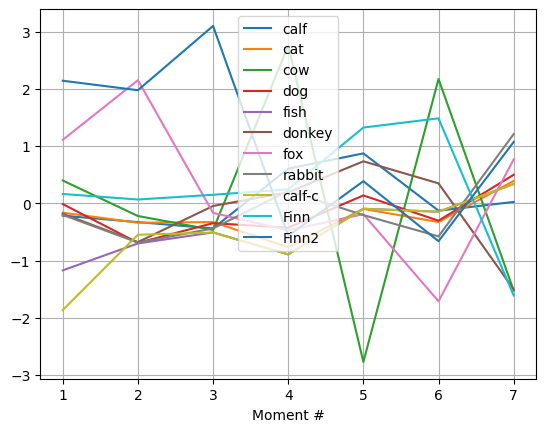

In [ ]:
HuVar = np.var(list(BaseHuMoments.values()), axis=0)
HuMean = np.mean(list(BaseHuMoments.values()), axis=0)
for name, moments in BaseHuMoments.items():
    plt.plot(np.arange(len(moments))+1, (moments - HuMean) / np.sqrt(HuVar), label=name)
plt.xlabel("Moment #")
plt.grid()
plt.legend()
plt.show()

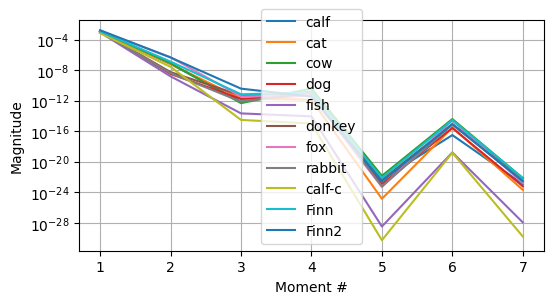

In [ ]:
plt.figure(figsize=(6,3))
for name, moments in BaseHuMoments.items():
    plt.semilogy(np.arange(len(moments))+1, np.abs(moments), label=name)
plt.xlabel("Moment #")
plt.ylabel("Magnitude")
plt.grid()
plt.legend()
plt.show()

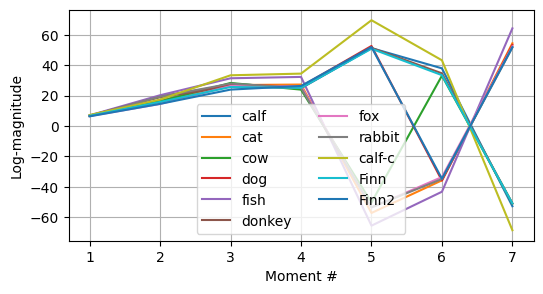

In [ ]:
plt.figure(figsize=(6,3))
for name, moments in BaseHuMoments.items():
    plt.plot(np.arange(len(moments))+1, -np.sign(moments) * np.log(np.abs(moments)), label=name)
plt.xlabel("Moment #")
plt.ylabel("Log-magnitude")
plt.legend(ncol=2)
plt.grid()
plt.show()

# Rotation

In [ ]:
# Rotate 20 degrees
Rot20Images = {}
for name, img in BaseImages.items():
    # Get image dimensions
    (h, w) = img.shape[:2]
    # Calculate the center of the image
    center = (w // 2, h // 2)

    # Define the rotation matrix
    angle = 20
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    # Perform the rotation
    rotated_img = cv2.warpAffine(img, M, (w, h))

    # Ensure the image is binary (0 or 1) after rotation for consistency with original intent
    # Apply a threshold to make it binary again, as rotation can introduce intermediate values
    _, binary_rotated_img = cv2.threshold(rotated_img, 127, 255, cv2.THRESH_BINARY)
    Rot20Images[name] = binary_rotated_img

Rot20HuMoments = {name: cv2.HuMoments(cv2.moments(img)) for name, img in Rot20Images.items()}

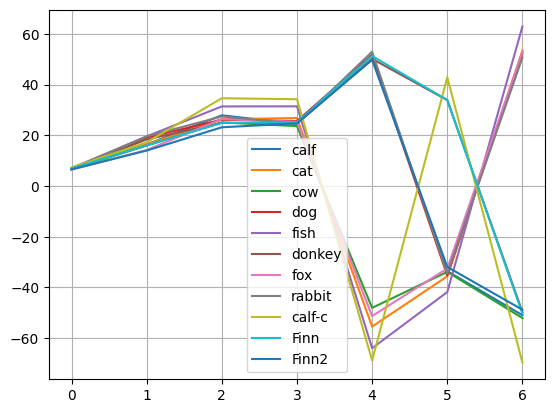

In [ ]:
for name, moments in Rot20HuMoments.items():
    plt.plot(-np.sign(moments) * np.log(np.abs(moments)), label=name)
plt.grid()
plt.legend()
plt.show()

In [ ]:
def EuclideanDistances(x_moments, y_moments):
    distances = np.zeros((len(x_moments.keys()), len(y_moments.keys())))
    for (i, n1), (j, n2) in  product(enumerate(x_moments.keys()), enumerate(y_moments.keys())):
        x_mom = -np.sign(x_moments[n1]) * np.log(np.abs(x_moments[n1]))
        y_mom = -np.sign(y_moments[n2]) * np.log(np.abs(y_moments[n2]))
        distances[i,j] = np.sqrt(np.sum(((x_mom - y_mom))**2))
    return {"dist": distances, "x_labels": list(x_moments.keys()), "y_labels": list(y_moments.keys())}

In [ ]:
def heatmap(distances, x_axis=None, y_axis=None):
    xrange = range(len(distances["x_labels"]))
    yrange = range(len(distances["y_labels"]))
    fig, ax = plt.subplots(figsize=(10,8))
    im = ax.imshow(distances["dist"])
    ax.set_xticks(xrange, labels=distances["x_labels"], rotation=90)
    ax.set_yticks(yrange, labels=distances["y_labels"], rotation=90, va="center")
    for i, j in product(xrange, yrange):
        ax.text(i, j, f"{distances["dist"][j, i]:.1f}", ha="center", va="center", color="w")
    fig.colorbar(im)
    if x_axis is not None:
        ax.set_xlabel(x_axis)
    if y_axis is not None:
        ax.set_ylabel(y_axis)
    plt.tight_layout()
    plt.show()

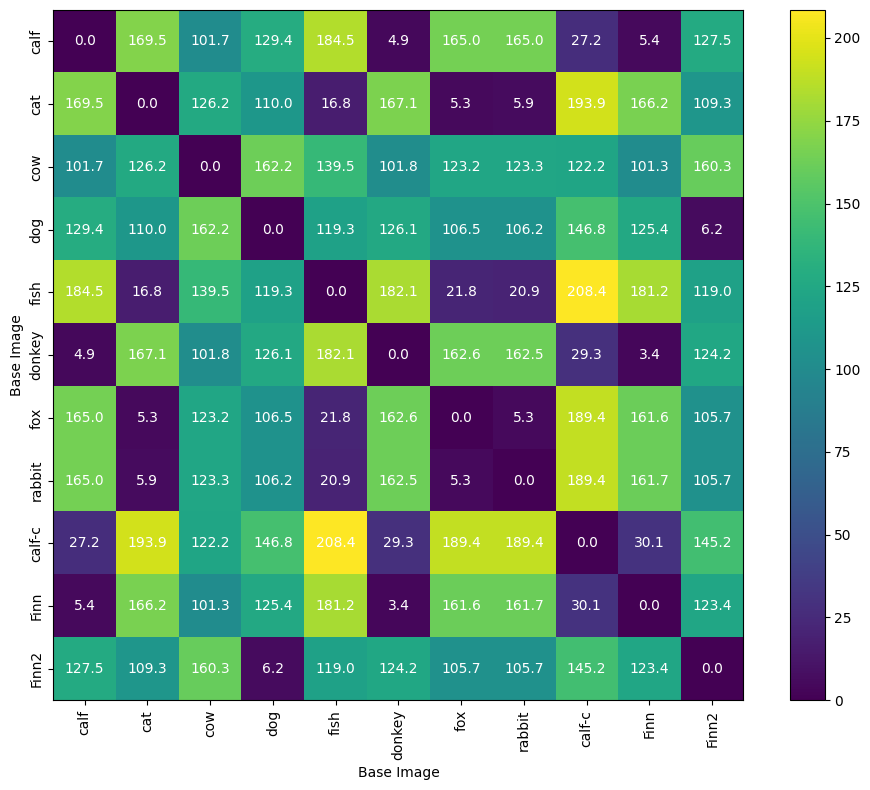

In [ ]:
heatmap(EuclideanDistances(BaseHuMoments, BaseHuMoments), "Base Image", "Base Image")

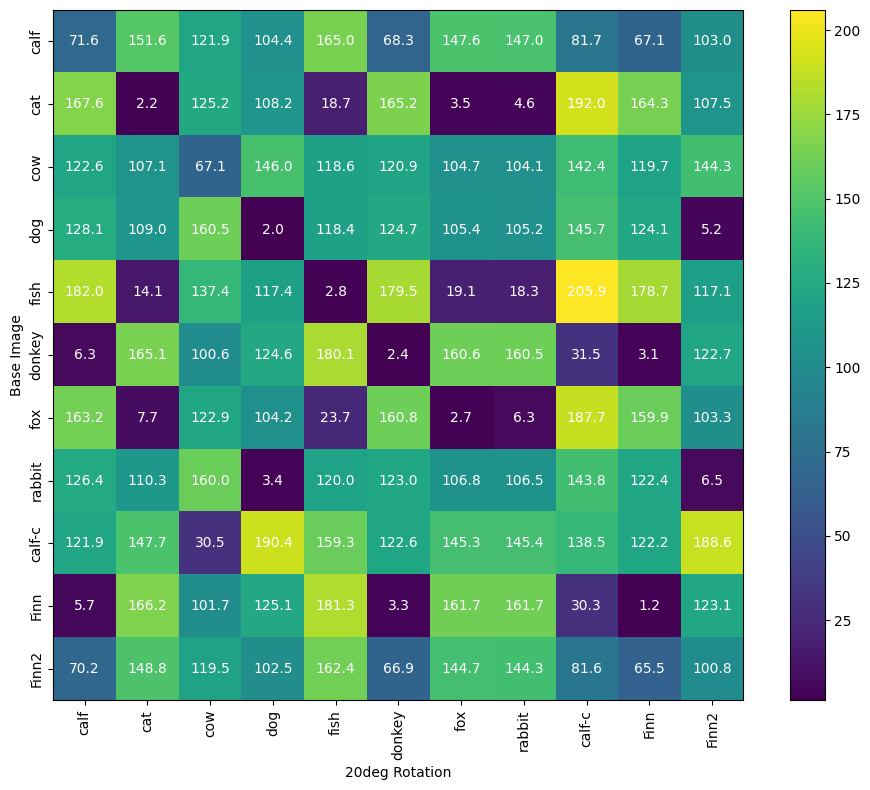

In [ ]:
heatmap(EuclideanDistances(Rot20HuMoments, BaseHuMoments), "20deg Rotation", "Base Image")

# Shift

In [ ]:
ShiftedImages = {}
for name, img in BaseImages.items():
    # Define the translation matrix
    tx = 10  # Shift by 10 pixels in x-direction
    ty = 5   # Shift by 5 pixels in y-direction
    M = np.float32([[1, 0, tx], [0, 1, ty]])

    # Get image dimensions
    (h, w) = img.shape[:2]

    # Perform the translation
    shifted_img = cv2.warpAffine(img, M, (w, h))

    # Ensure the image is binary after shifting for consistency
    _, binary_shifted_img = cv2.threshold(shifted_img, 127, 255, cv2.THRESH_BINARY)
    ShiftedImages[name] = binary_shifted_img

ShiftedHuMoments = {name: cv2.HuMoments(cv2.moments(img)) for name, img in ShiftedImages.items()}

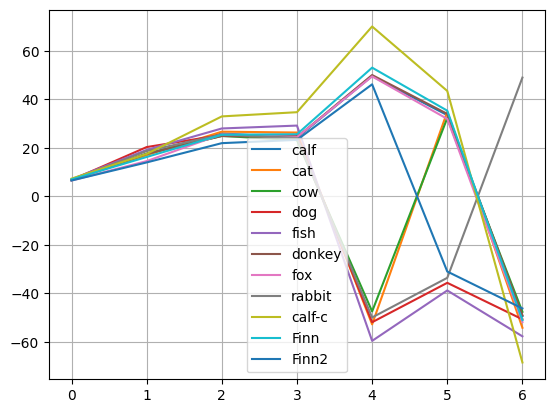

In [ ]:
for name, moments in ShiftedHuMoments.items():
    plt.plot(-np.sign(moments) * np.log(np.abs(moments)), label=name)
plt.grid()
plt.legend()
plt.show()

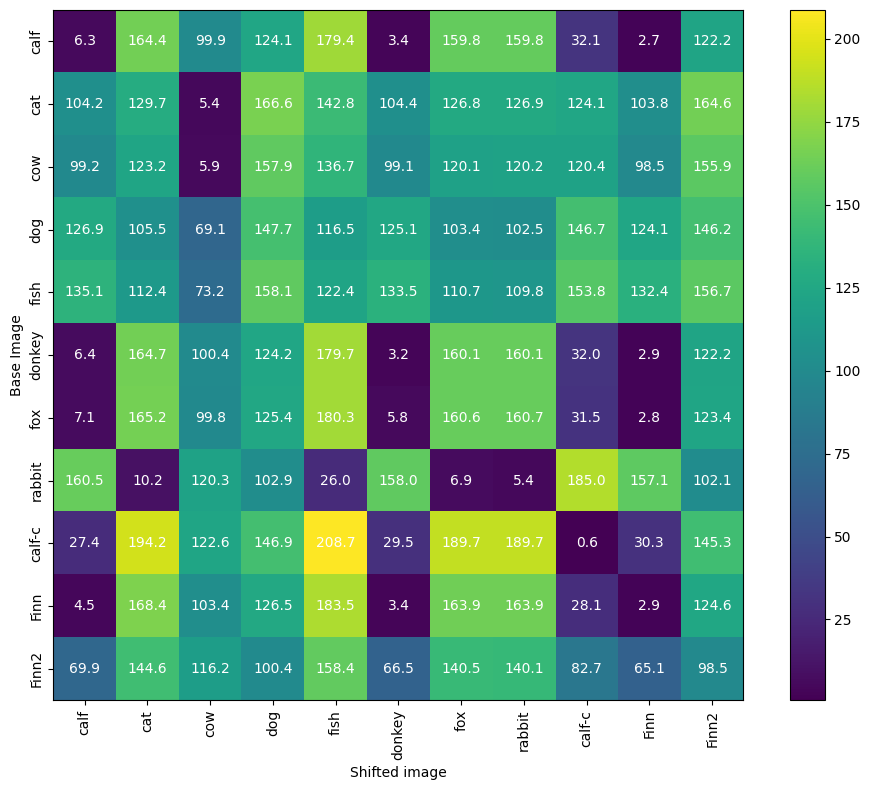

In [ ]:
heatmap(EuclideanDistances(ShiftedHuMoments, BaseHuMoments), "Shifted image", "Base Image")

#Zoom-out

In [ ]:
ZoomOutImages = {}
for name, img in BaseImages.items():
    # Get image dimensions
    (h, w) = img.shape[:2]

    # Define zoom out factor (e.g., 0.8 means 80% of original size)
    zoom_factor = 0.8
    new_w, new_h = int(w * zoom_factor), int(h * zoom_factor)

    # Resize the image
    resized_img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Create a new blank canvas of original size
    zoomed_out_canvas = np.zeros((h, w), dtype=np.uint8)

    # Calculate position to center the resized image
    x_offset = (w - new_w) // 2
    y_offset = (h - new_h) // 2

    # Place the resized image onto the center of the canvas
    zoomed_out_canvas[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized_img

    # Ensure the image is binary after zoom out for consistency
    _, binary_zoomed_img = cv2.threshold(zoomed_out_canvas, 127, 255, cv2.THRESH_BINARY)
    ZoomOutImages[name] = binary_zoomed_img

ZoomOutHuMoments = {name: cv2.HuMoments(cv2.moments(img)) for name, img in ZoomOutImages.items()}

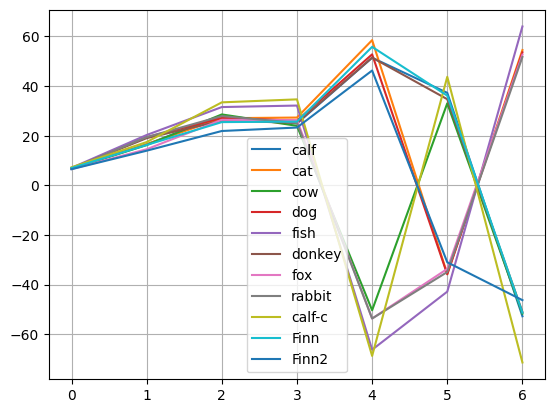

In [ ]:
for name, moments in ZoomOutHuMoments.items():
    plt.plot(-np.sign(moments) * np.log(np.abs(moments)), label=name)
plt.grid()
plt.legend()
plt.show()

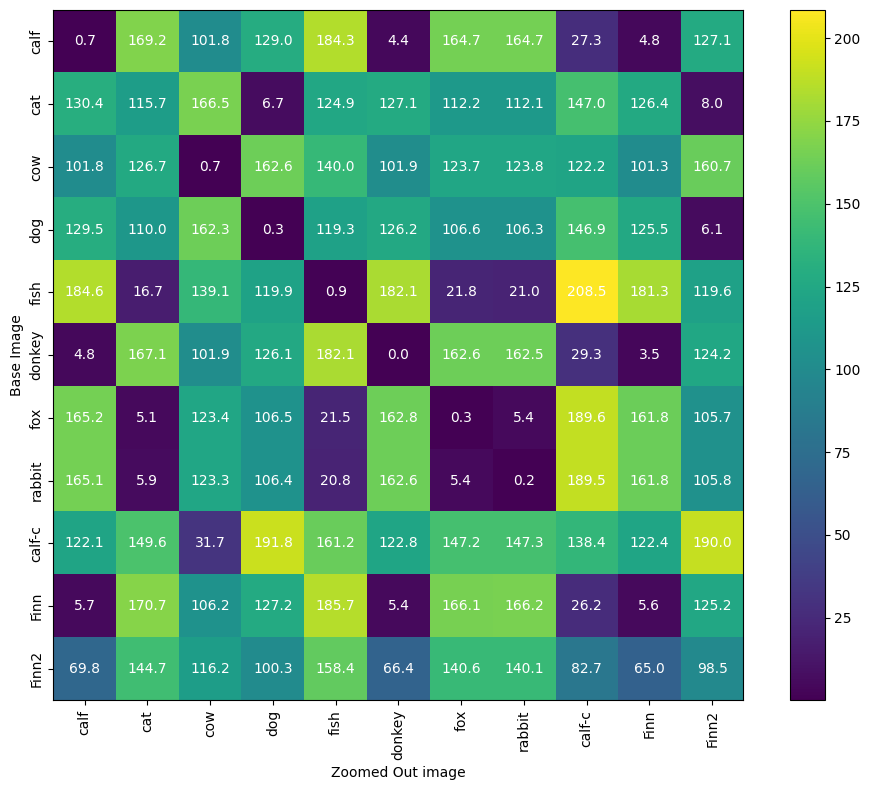

In [ ]:
heatmap(EuclideanDistances(ZoomOutHuMoments, BaseHuMoments), "Zoomed Out image", "Base Image")

# Gaussian Noise

In [ ]:
def add_gaussian_noise_and_binarize(image, mean=0, sigma=30, threshold_val=127):
    """
    Adds Gaussian noise to an image and then binarizes it.
    Args:
        image (np.ndarray): The input image (expected uint8, 0 or 255).
        mean (float): Mean of the Gaussian noise.
        sigma (float): Standard deviation of the Gaussian noise (controls noise level).
        threshold_val (int): Threshold value for binarization.
    Returns:
        np.ndarray: The binarized noisy image (uint8, 0 or 255).
    """
    # Convert image to float for noise addition
    image_float = image.astype(np.float32)

    # Generate Gaussian noise
    gaussian_noise = np.random.normal(mean, sigma, image.shape).astype(np.float32)

    # Add noise and clip values to be within [0, 255]
    noisy_image = image_float + gaussian_noise
    noisy_image = np.clip(noisy_image, 0, 255)

    # Binarize the noisy image using the threshold_val
    _, binary_noisy_image = cv2.threshold(noisy_image.astype(np.uint8), threshold_val, 255, cv2.THRESH_BINARY)
    return binary_noisy_image

In [ ]:
Noise5dBImages = {}
# Using a sigma value for 5dB noise (higher sigma means more noise)
sigma_5dB = 30 # This value can be tuned

for name, img in BaseImages.items():
    noisy_img = add_gaussian_noise_and_binarize(img, sigma=sigma_5dB)
    Noise5dBImages[name] = noisy_img

Noise5dBHuMoments = {name: cv2.HuMoments(cv2.moments(img)) for name, img in Noise5dBImages.items()}

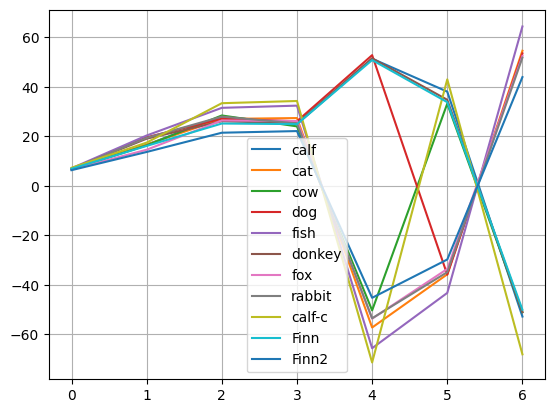

In [ ]:
for name, moments in Noise5dBHuMoments.items():
    plt.plot(-np.sign(moments) * np.log(np.abs(moments)), label=name)
plt.grid()
plt.legend()
plt.show()

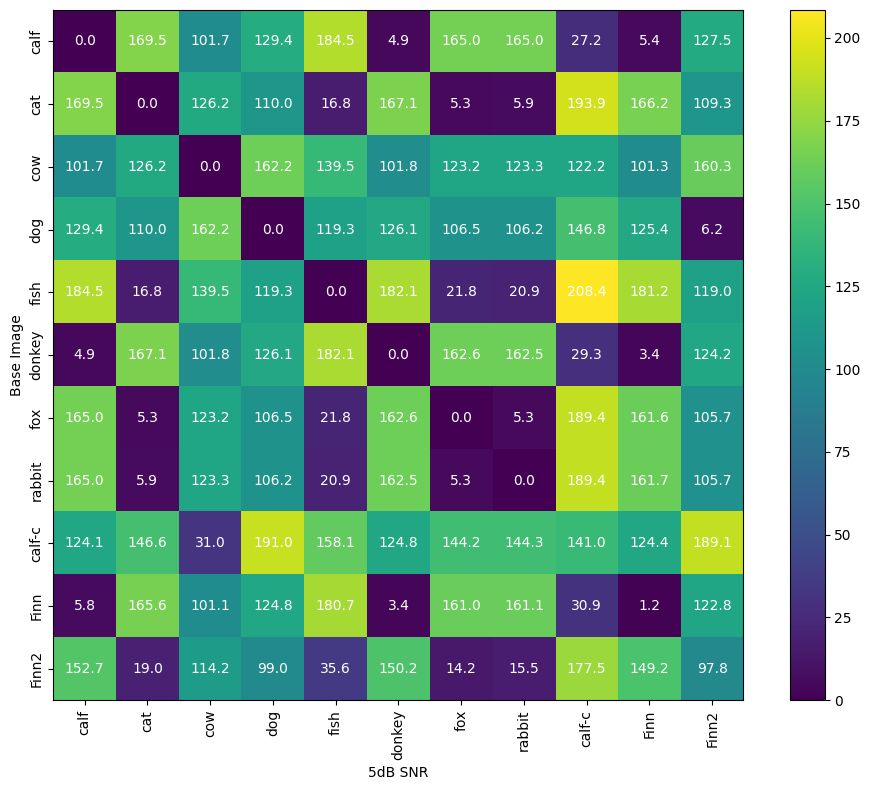

In [ ]:
heatmap(EuclideanDistances(Noise5dBHuMoments, BaseHuMoments), "5dB SNR", "Base Image")

In [ ]:
Noise10dBImages = {}
# Using a sigma value for 5dB noise (higher sigma means more noise)
sigma_10dB = 100

for name, img in BaseImages.items():
    noisy_img = add_gaussian_noise_and_binarize(img, sigma=sigma_10dB)
    Noise5dBImages[name] = noisy_img

Noise10dBHuMoments = {name: cv2.HuMoments(cv2.moments(img)) for name, img in Noise5dBImages.items()}

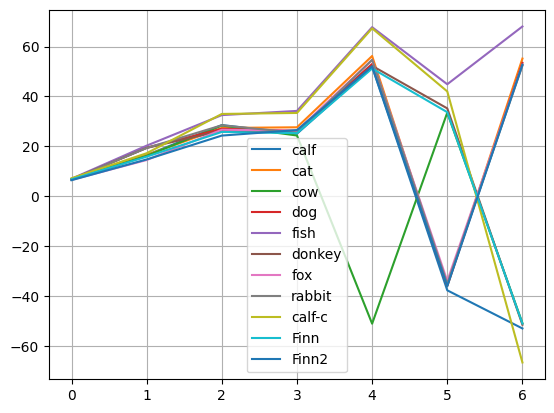

In [ ]:
for name, moments in Noise10dBHuMoments.items():
    plt.plot(-np.sign(moments) * np.log(np.abs(moments)), label=name)
plt.grid()
plt.legend()
plt.show()

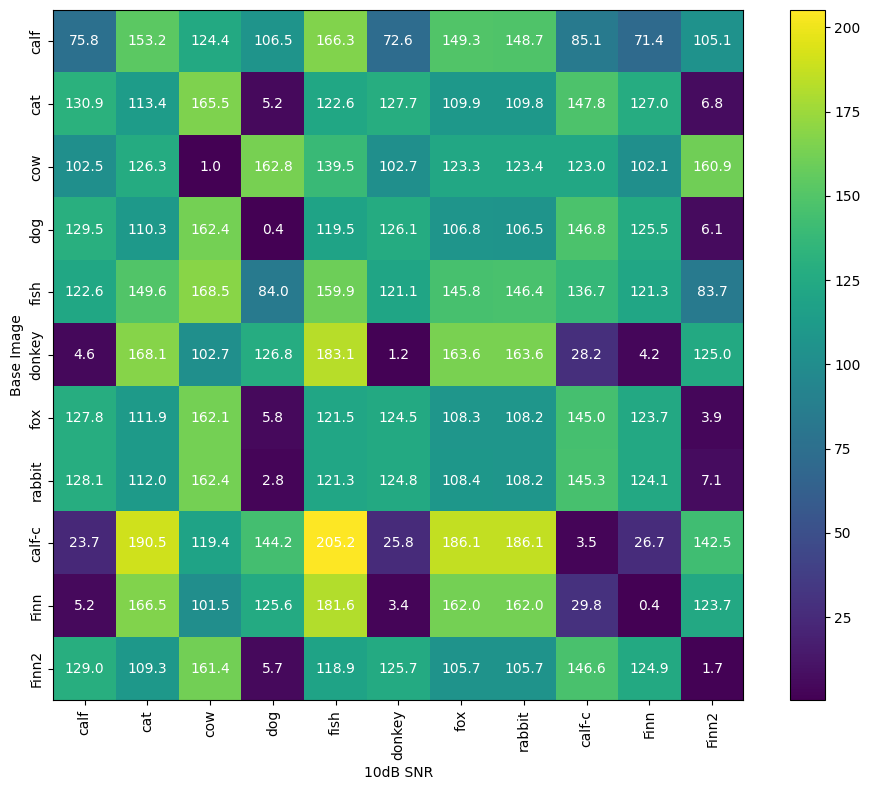

In [ ]:
heatmap(EuclideanDistances(Noise10dBHuMoments, BaseHuMoments), "10dB SNR", "Base Image")

# Occlude

In [ ]:
OccludeImages = {}
for name, img in BaseImages.items():
    # Get image dimensions
    (h, w) = img.shape[:2]

    # Create a copy of the image to occlude
    occluded_img = img.copy()

    # Define the occlusion rectangle (e.g., a central square of 30% of image size)
    occlusion_width = int(w * 0.3)
    occlusion_height = int(h * 0.3)

    # Calculate top-left and bottom-right corners for the rectangle
    x_start = (w - occlusion_width) // 2
    y_start = (h - occlusion_height) // 2
    x_end = x_start + occlusion_width
    y_end = y_start + occlusion_height

    # Draw a black rectangle to occlude the central part of the image
    cv2.rectangle(occluded_img, (x_start, y_start), (x_end, y_end), 0, -1) # 0 for black, -1 for filled

    # Ensure the image is binary after occlusion for consistency
    _, binary_occluded_img = cv2.threshold(occluded_img, 127, 255, cv2.THRESH_BINARY)
    OccludeImages[name] = binary_occluded_img

OccludeHuMoments = {name: cv2.HuMoments(cv2.moments(img)) for name, img in OccludeImages.items()}

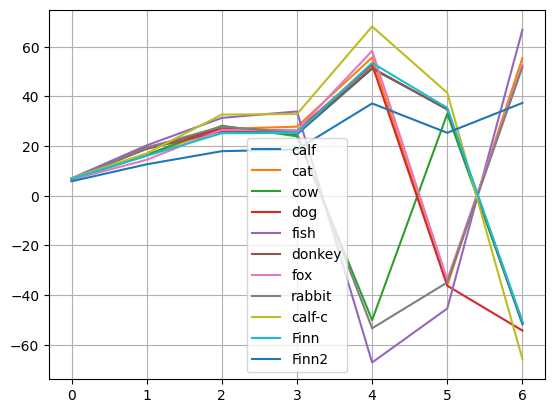

In [ ]:
for name, moments in OccludeHuMoments.items():
    plt.plot(-np.sign(moments) * np.log(np.abs(moments)), label=name)
plt.grid()
plt.legend()
plt.show()

188.10464286520386


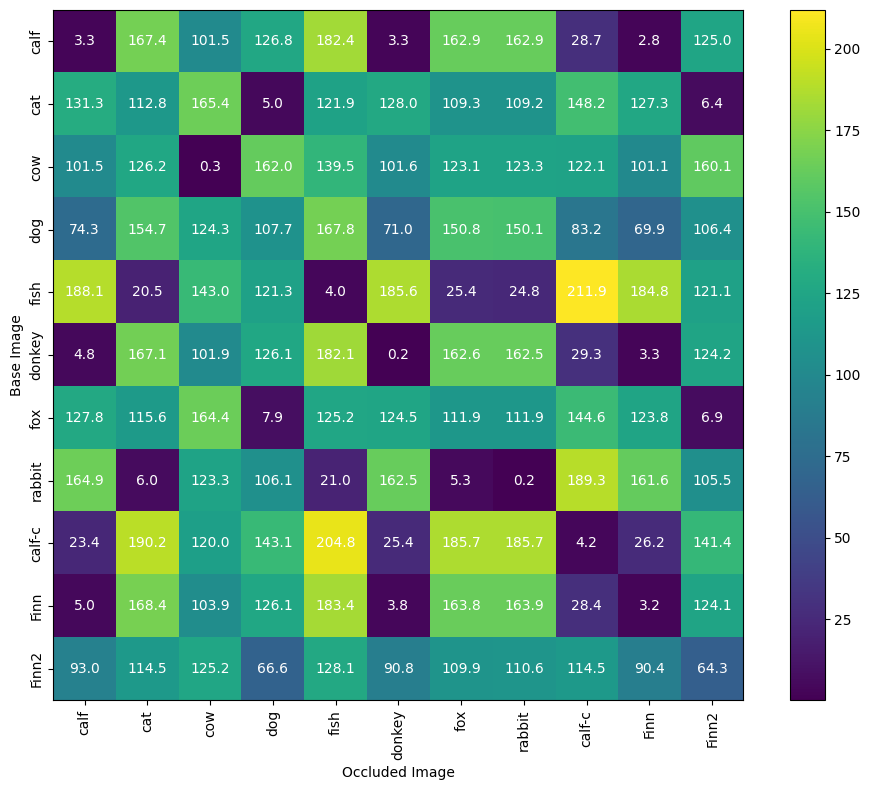

In [ ]:
print(EuclideanDistances(OccludeHuMoments, BaseHuMoments)["dist"][4,0])
heatmap(EuclideanDistances(OccludeHuMoments, BaseHuMoments), "Occluded Image", "Base Image")

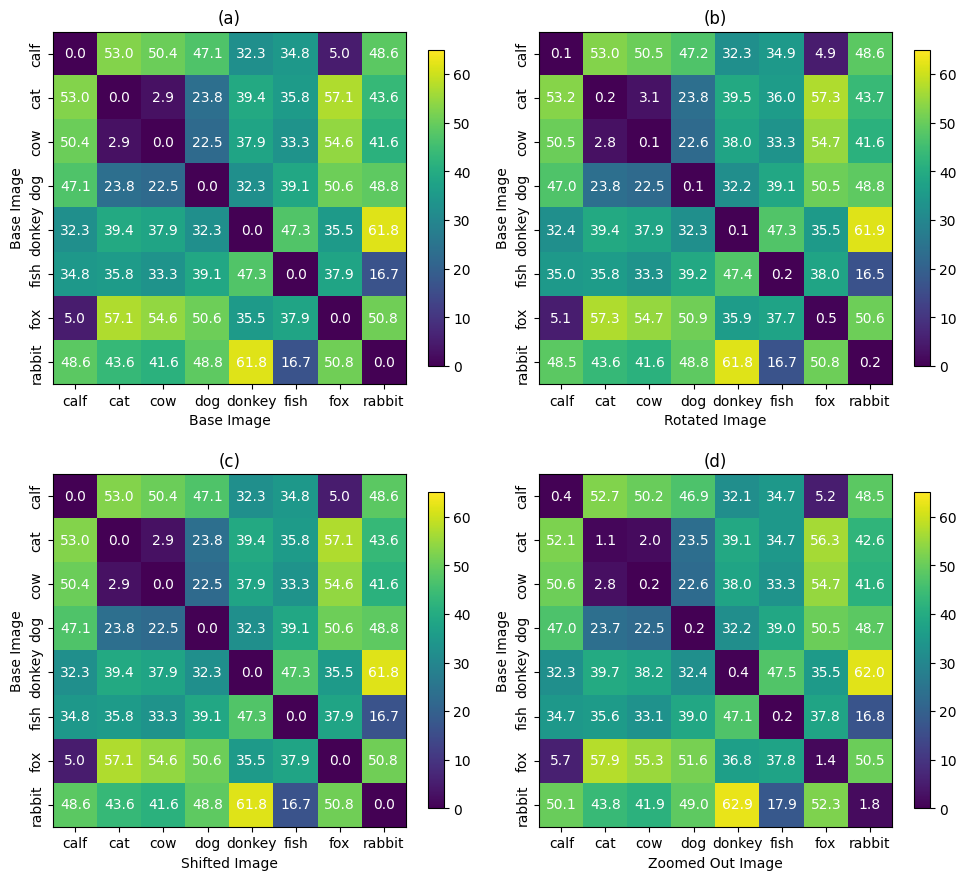

In [ ]:
BaseDist = EuclideanDistances(BaseHuMoments, BaseHuMoments)
Rot20Dist = EuclideanDistances(Rot20HuMoments, BaseHuMoments)
ShiftedDist = EuclideanDistances(ShiftedHuMoments, BaseHuMoments)
ZoomOutDist = EuclideanDistances(ZoomOutHuMoments, BaseHuMoments)

distances = BaseDist
xrange = range(len(distances["x_labels"]))
yrange = range(len(distances["y_labels"]))
fig, axes = plt.subplots(2, 2, figsize=(10,9))
for idx, (dist, xlbl, ax) in enumerate(zip((BaseDist, Rot20Dist, ShiftedDist, ZoomOutDist), ["Base Image", "Rotated Image", "Shifted Image", "Zoomed Out Image"], axes.flatten())):
    im = ax.imshow(dist["dist"], vmin=0, vmax=65)
    ax.set_xticks(xrange, labels=dist["x_labels"])
    ax.set_yticks(yrange, labels=dist["y_labels"], rotation=90, va="center")
    for i, j in product(xrange, yrange):
        ax.text(i, j, f"{dist["dist"][j, i]:.1f}", ha="center", va="center", color="w")
    ax.set_title(f"({chr(ord("a")+idx)})")
    ax.set_ylabel("Base Image")
    ax.set_xlabel(xlbl)
    fig.colorbar(im, shrink=.8)
plt.tight_layout()
plt.show()

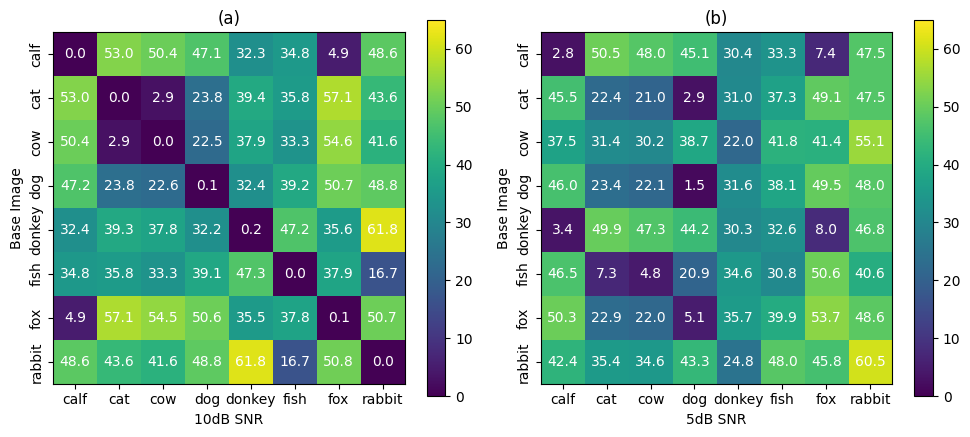

In [ ]:
Noise10dBDist = EuclideanDistances(Noise10dBHuMoments, BaseHuMoments)
Noise5dBDist = EuclideanDistances(Noise5dBHuMoments, BaseHuMoments)

distances = BaseDist
xrange = range(len(distances["x_labels"]))
yrange = range(len(distances["y_labels"]))
fig, axes = plt.subplots(1, 2, figsize=(10,5))
for idx, (dist, xlbl, ax) in enumerate(zip((Noise10dBDist, Noise5dBDist), ["10dB SNR", "5dB SNR"], axes.flatten())):
    im = ax.imshow(dist["dist"], vmin=0, vmax=65)
    ax.set_xticks(xrange, labels=dist["x_labels"])
    ax.set_yticks(yrange, labels=dist["y_labels"], rotation=90, va="center")
    for i, j in product(xrange, yrange):
        ax.text(i, j, f"{dist["dist"][j, i]:.1f}", ha="center", va="center", color="w")
    ax.set_title(f"({chr(ord("a")+idx)})")
    ax.set_ylabel("Base Image")
    ax.set_xlabel(xlbl)
    fig.colorbar(im, shrink=.8)
plt.tight_layout()
plt.show()